In [247]:
print("Hello World")

Hello World


In [248]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df_reservations = pd.read_csv('ressources/reservations_train.csv')

# Afficher les 5 premières lignes du DataFrame
display(df_reservations.head())

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,...,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,...,0,0,2.0,1,0,0,0,0,NaN,0


In [249]:
# Charger le fichier CSV du dictionnaire de données dans un DataFrame
df_data_dictionary = pd.read_csv('ressources/data_dictionary.csv')

# Afficher toutes les lignes du DataFrame du dictionnaire de données
display(df_data_dictionary)

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


In [250]:
print("Nombre de lignes :", df_reservations.shape[0])
print("Nombre de colonnes :", df_reservations.shape[1])
df_reservations.info()

Nombre de lignes : 8000
Nombre de colonnes : 34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reservation_id             8000 non-null   object 
 1   date_reservation           8000 non-null   object 
 2   date_arrivee               8000 non-null   object 
 3   region_hotel               8000 non-null   object 
 4   ville                      8000 non-null   object 
 5   type_destination           8000 non-null   object 
 6   hotel_id                   8000 non-null   object 
 7   categorie_hotel            8000 non-null   int64  
 8   segment_client             8000 non-null   object 
 9   marche_origine             7809 non-null   object 
 10  canal_reservation          8000 non-null   object 
 11  moyen_transport            8000 non-null   object 
 12  delai_reservation_jours    8000 non-null   int64  
 13  

In [251]:
df_reservations.describe(include="object")

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,segment_client,marche_origine,canal_reservation,moyen_transport,formule_repas,tarif_remboursable,type_acompte,client_type,agent_id
count,8000,8000,8000,8000,8000,8000,8000,8000,7809,8000,8000,8000,8000,8000,8000,4646
unique,8000,875,979,10,10,10,84,5,6,5,5,4,2,3,3,45
top,R000808,2023-12-15,2023-09-10,Lazio,Roma,urbaine_culturelle,LAZ-4-1,loisirs_couple,Italie,plateforme_en_ligne,train,petit_dejeuner,oui,aucun,nouveau,AG027
freq,1,20,19,1349,1349,1349,271,2331,2860,3321,2492,4307,5481,3835,5021,127


In [252]:
colonnes_categorielles = df_reservations.select_dtypes(include="object").columns

print(colonnes_categorielles)

Index(['reservation_id', 'date_reservation', 'date_arrivee', 'region_hotel',
       'ville', 'type_destination', 'hotel_id', 'segment_client',
       'marche_origine', 'canal_reservation', 'moyen_transport',
       'formule_repas', 'tarif_remboursable', 'type_acompte', 'client_type',
       'agent_id'],
      dtype='object')


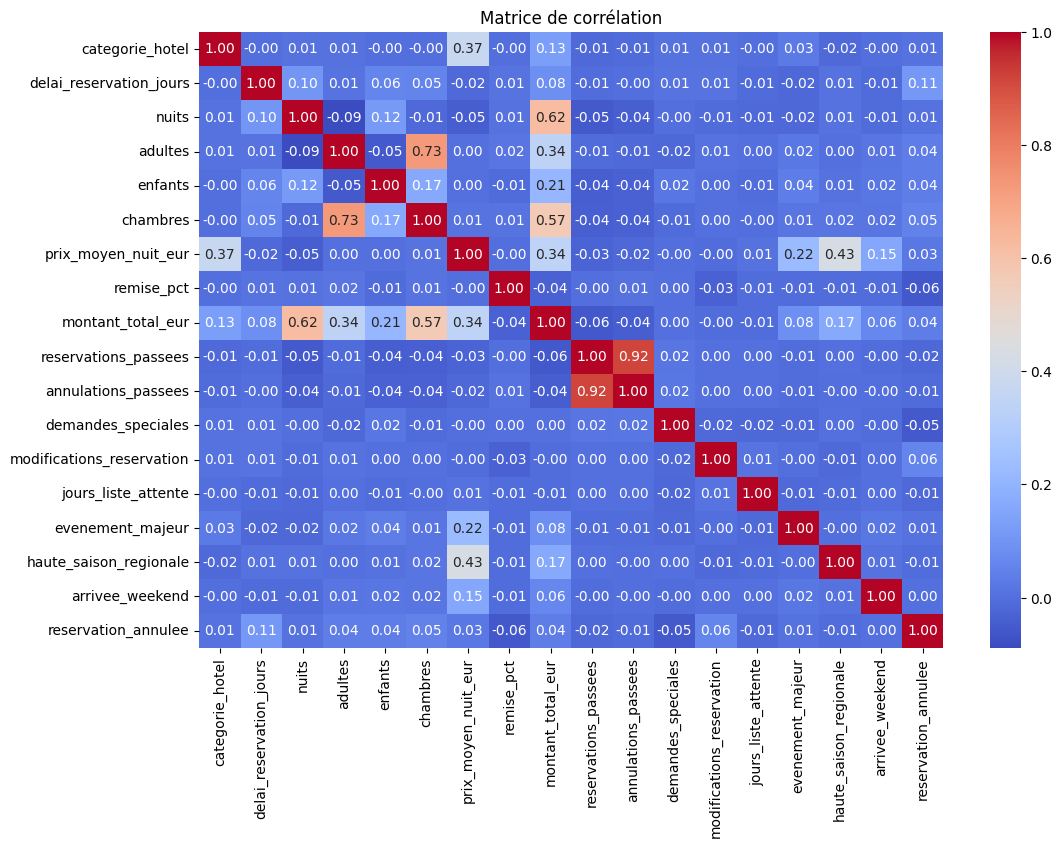

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Calculer la corrélation uniquement pour les colonnes numériques
correlation = df_reservations.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

### Encodage des Variables Catégorielles

Pour que les modèles de machine learning puissent utiliser les variables non numériques (catégorielles), il faut les transformer en format numérique. L'une des techniques les plus utilisées est l'**encodage One-Hot** (ou `pd.get_dummies`), qui crée une nouvelle colonne binaire pour chaque catégorie unique d'une variable. Si une réservation appartient à une catégorie, la valeur de cette colonne sera de 1, et 0 sinon.

Nous allons appliquer cela à quelques-unes des colonnes catégorielles identifiées précédemment.

In [254]:
# Sélectionner quelques colonnes catégorielles à encoder (vous pouvez ajuster cette liste)
colonnes_a_encoder = ['region_hotel', 'type_destination', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'formule_repas', 'tarif_remboursable', 'type_acompte', 'client_type']

# Appliquer l'encodage One-Hot
df_encoded = pd.get_dummies(df_reservations, columns=colonnes_a_encoder, drop_first=True) # drop_first=True évite la multicolinéarité

# Afficher les premières lignes du DataFrame avec les colonnes encodées
display(df_encoded.head())

# Afficher les nouvelles colonnes créées
print("Nouvelles colonnes après encodage :\n", [col for col in df_encoded.columns if '_' in col and col.split('_')[0] in colonnes_a_encoder])

,reservation_id,date_reservation,date_arrivee,ville,hotel_id,categorie_hotel,delai_reservation_jours,nuits,adultes,enfants,...,moyen_transport_train,moyen_transport_voiture,formule_repas_demi_pension,formule_repas_pension_complete,formule_repas_petit_dejeuner,tarif_remboursable_oui,type_acompte_partiel,type_acompte_total,client_type_fidele,client_type_nouveau
0,R000808,2023-01-01,2023-03-13,Napoli,CAM-4-2,4,71,4,2,0.0,...,False,False,False,False,False,False,False,True,False,True
1,R001808,2023-01-01,2023-01-07,Roma,LAZ-4-3,4,6,3,2,1.0,...,True,False,False,False,True,True,True,False,True,False
2,R002130,2023-01-01,2023-03-26,Milano,LOM-4-2,4,84,3,2,0.0,...,False,False,False,False,False,True,False,False,False,True
3,R003635,2023-01-01,2023-01-09,Genova,LIG-4-1,4,8,3,2,1.0,...,False,True,False,False,True,True,False,False,False,True
4,R004683,2023-01-01,2023-01-11,Cagliari,SAR-3-2,3,10,4,2,0.0,...,False,False,False,False,True,False,False,True,False,True


Nouvelles colonnes après encodage :
 []


Pour vérifier les colonnes nouvellement créées après l'encodage One-Hot, nous pouvons comparer les colonnes de `df_encoded` avec celles de `df_reservations`.

In [255]:
# Obtenir les noms des colonnes du DataFrame original
col_originales = df_reservations.columns

# Obtenir les noms des colonnes du DataFrame encodé
col_encodees = df_encoded.columns

# Identifier les nouvelles colonnes (celles qui sont dans df_encoded mais pas dans df_reservations)
nouvelles_colonnes_creees = [col for col in col_encodees if col not in col_originales]

print(f"Nombre de nouvelles colonnes créées : {len(nouvelles_colonnes_creees)}")
print("Nouvelles colonnes créées après encodage One-Hot :\n", nouvelles_colonnes_creees)

Nombre de nouvelles colonnes créées : 43
Nouvelles colonnes créées après encodage One-Hot :
 ['region_hotel_Lazio', 'region_hotel_Liguria', 'region_hotel_Lombardia', 'region_hotel_Puglia', 'region_hotel_Sardegna', 'region_hotel_Sicilia', 'region_hotel_Toscana', 'region_hotel_Trentino-Alto_Adige', 'region_hotel_Veneto', 'type_destination_balneaire_rurale', 'type_destination_culturelle_rurale', 'type_destination_insulaire_balneaire', 'type_destination_insulaire_mixte', 'type_destination_littorale', 'type_destination_montagne', 'type_destination_urbaine_cotiere', 'type_destination_urbaine_culturelle', 'type_destination_urbaine_littorale', 'segment_client_famille', 'segment_client_groupe', 'segment_client_loisirs_couple', 'segment_client_solo', 'marche_origine_Asie_Pacifique', 'marche_origine_Autres', 'marche_origine_Europe_Centrale', 'marche_origine_Europe_Ouest', 'marche_origine_Italie', 'canal_reservation_entreprise', 'canal_reservation_plateforme_en_ligne', 'canal_reservation_site_hote

### Matrice de Corrélation avec les Variables Encodées

Nous allons maintenant calculer la matrice de corrélation pour le DataFrame `df_encoded`, qui inclut les variables originales (numériques et non encodées comme `date_reservation`, `reservation_id`, etc.) ainsi que les nouvelles colonnes créées par l'encodage One-Hot. Puis, nous visualiserons cette matrice pour comprendre les relations entre toutes les caractéristiques numériques.

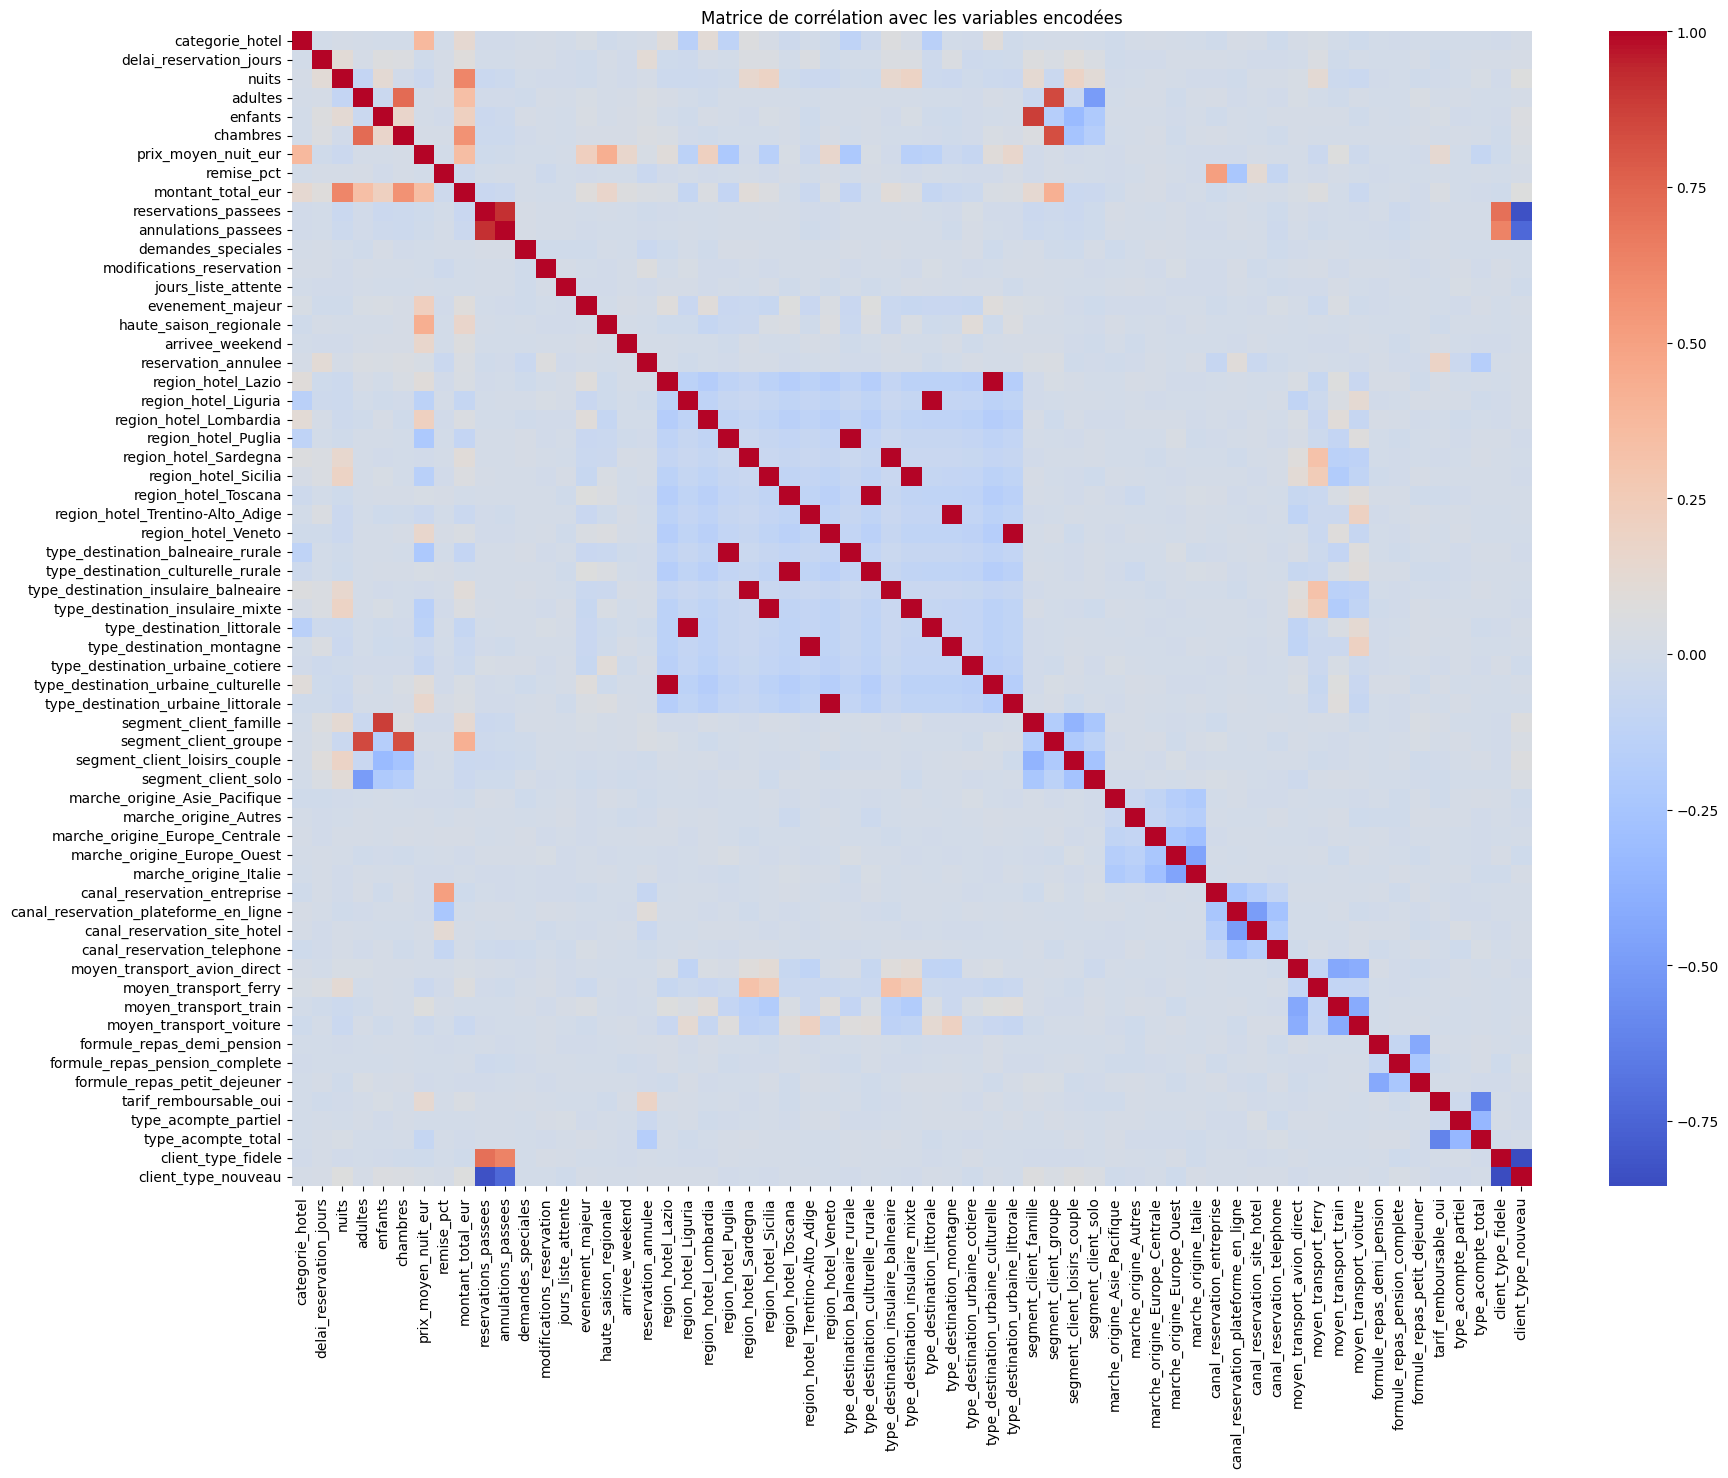

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15)) # Ajuster la taille pour une meilleure visibilité

# Calculer la corrélation pour le DataFrame encodé, en incluant toutes les colonnes numériques
# Nous allons exclure les colonnes 'reservation_id', 'date_reservation', 'date_arrivee', 'ville', 'hotel_id', 'agent_id' car elles ne sont pas numériques ou sont des identifiants et n'ont pas de sens dans une corrélation directe.
col_to_exclude = ['reservation_id', 'date_reservation', 'date_arrivee', 'ville', 'hotel_id', 'agent_id']
df_correlation_ready = df_encoded.drop(columns=col_to_exclude, errors='ignore')

correlation_encoded = df_correlation_ready.corr(numeric_only=True)

sns.heatmap(
    correlation_encoded,
    annot=False, # Définir sur False pour éviter un graphique illisible avec trop de colonnes
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation avec les variables encodées")
plt.show()

### Corrélation avec la Variable Cible `reservation_annulee`

Pour mieux comprendre quelles variables sont les plus liées à l'annulation d'une réservation, nous allons extraire et afficher les coefficients de corrélation de toutes les caractéristiques avec la colonne `reservation_annulee`.

In [257]:
# Calculer les corrélations de toutes les colonnes avec 'reservation_annulee'
# df_correlation_ready contient déjà les colonnes encodées et exclut les identifiants/dates non pertinents.
correlations_with_target = df_correlation_ready.corr()['reservation_annulee']

# Supprimer la corrélation de la variable avec elle-même (qui est toujours 1)
correlations_with_target = correlations_with_target.drop('reservation_annulee')

# Trier les corrélations par valeur absolue pour voir les influences les plus fortes
correlations_with_target_sorted = correlations_with_target.abs().sort_values(ascending=False)

# Afficher les corrélations (avec leurs signes originaux)
display(correlations_with_target[correlations_with_target_sorted.index].to_frame(name='Corrélation avec reservation_annulee'))

,Corrélation avec reservation_annulee
tarif_remboursable_oui,0.183118
type_acompte_total,-0.172591
delai_reservation_jours,0.110531
canal_reservation_plateforme_en_ligne,0.088630
canal_reservation_entreprise,-0.075404
modifications_reservation,0.059761
canal_reservation_site_hotel,-0.057322
remise_pct,-0.055104
demandes_speciales,-0.054611
chambres,0.049157


### Variables les Plus Corrélées avec l'Annulation

Pour identifier les variables les plus corrélées à `reservation_annulee`, nous pouvons examiner le haut de la liste triée par valeur absolue de corrélation. Ces variables ont la plus forte influence (positive ou négative) sur la décision d'annuler une réservation.

In [258]:
# Afficher les 10 premières variables les plus corrélées avec 'reservation_annulee'
print("Top 10 des variables les plus corrélées avec 'reservation_annulee':")
display(correlations_with_target[correlations_with_target_sorted.index].head(10).to_frame(name='Corrélation avec reservation_annulee'))

Top 10 des variables les plus corrélées avec 'reservation_annulee':


,Corrélation avec reservation_annulee
tarif_remboursable_oui,0.183118
type_acompte_total,-0.172591
delai_reservation_jours,0.110531
canal_reservation_plateforme_en_ligne,0.088630
canal_reservation_entreprise,-0.075404
modifications_reservation,0.059761
canal_reservation_site_hotel,-0.057322
remise_pct,-0.055104
demandes_speciales,-0.054611
chambres,0.049157


### Visualisation de la Distribution des Variables Clés

Pour mieux appréhender l'impact des variables les plus corrélées sur `reservation_annulee`, nous allons les visualiser à l'aide de box plots. Ces graphiques montreront la distribution de chaque variable pour les réservations annulées (1) et non annulées (0).

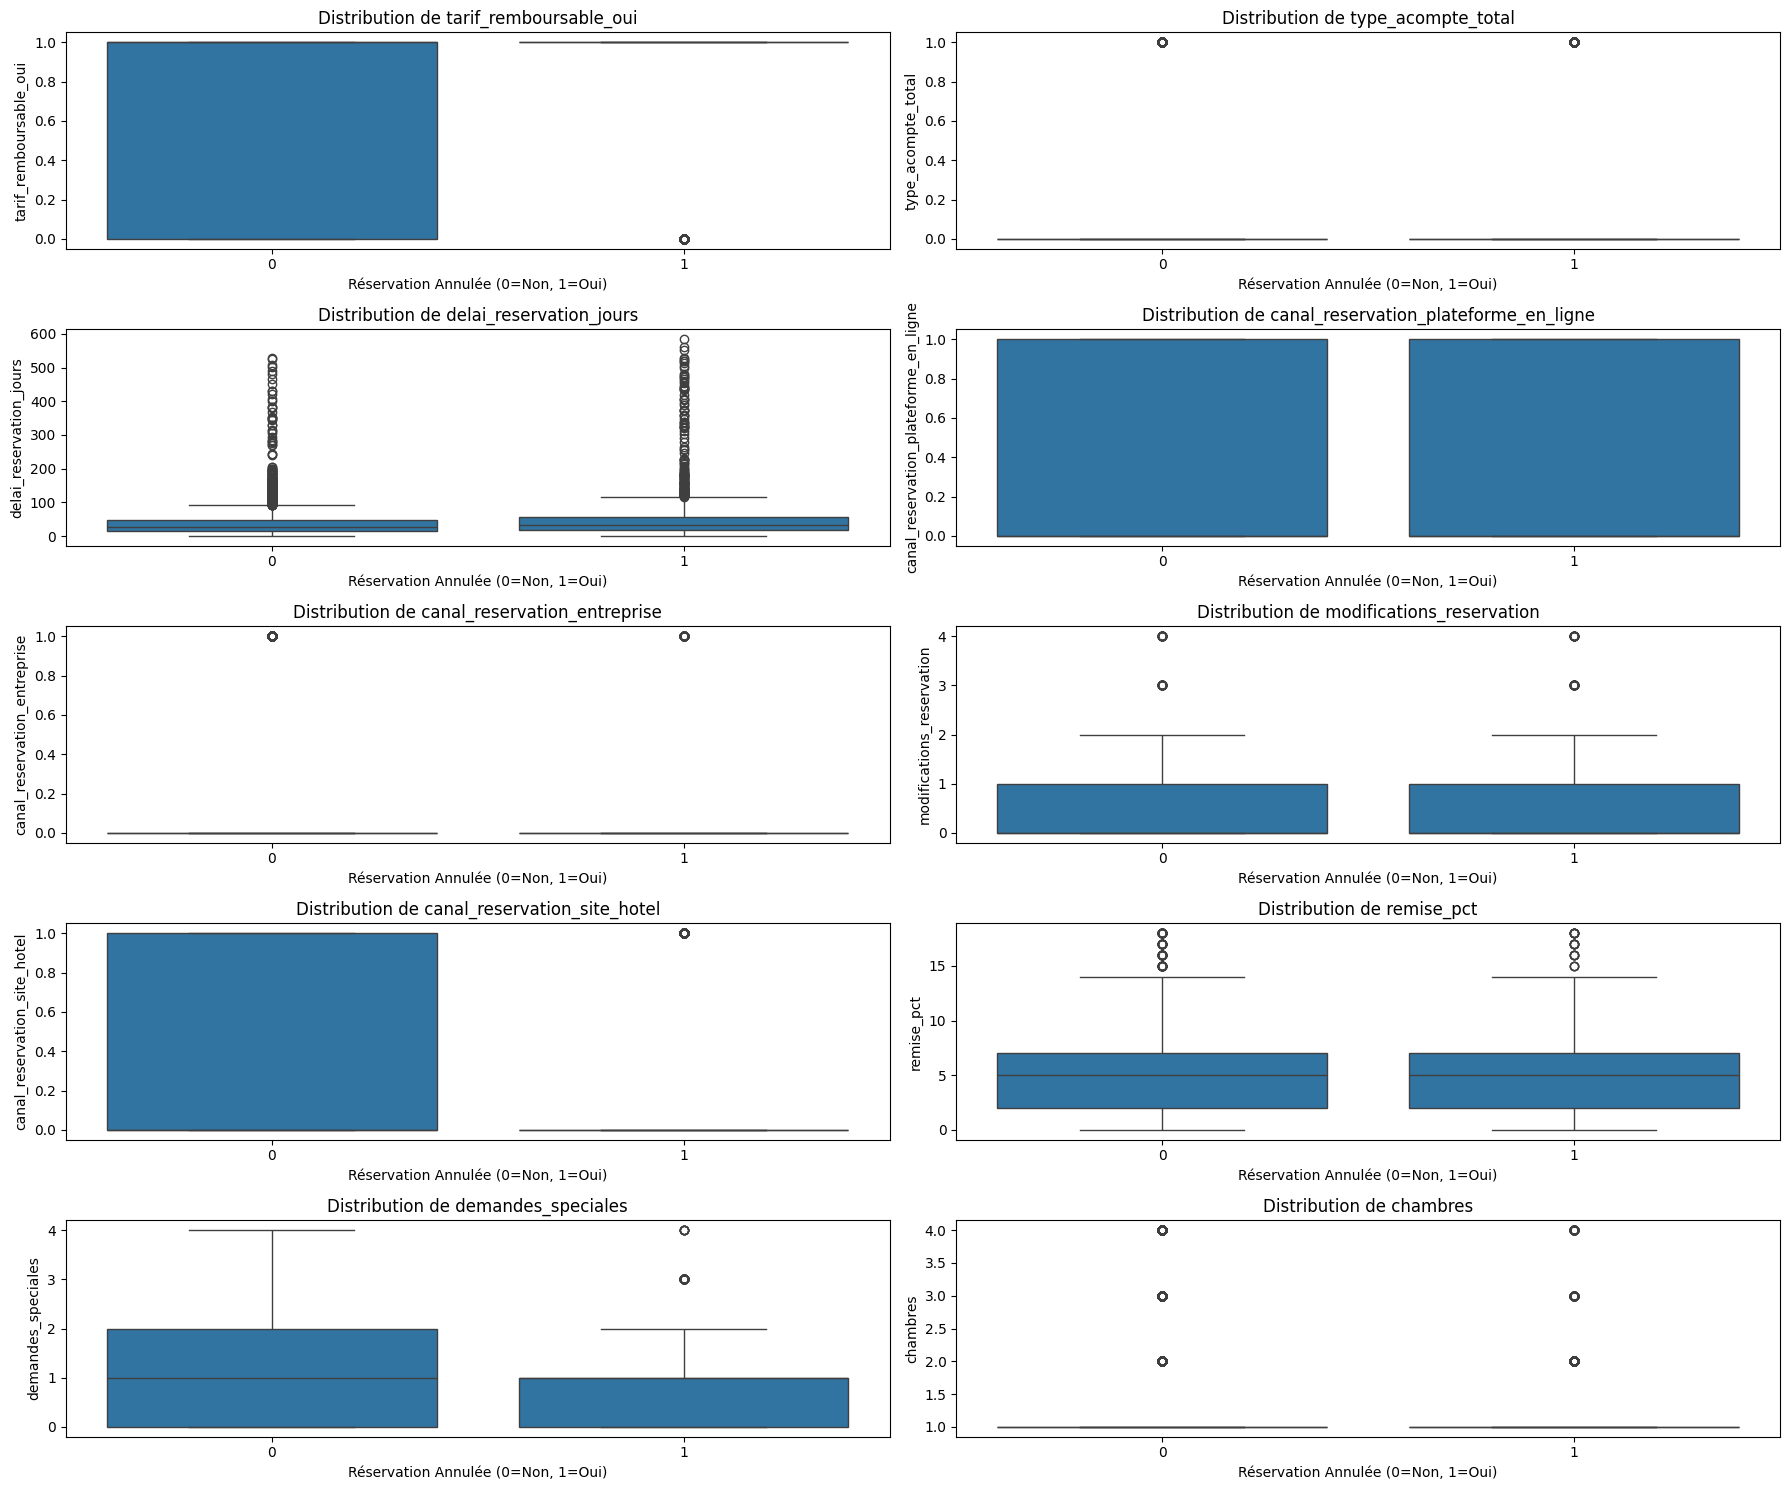

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtenir les noms des 10 variables les plus corrélées (sans la cible elle-même)
top_10_correlated_vars = correlations_with_target_sorted.head(10).index.tolist()

# Créer des box plots pour chaque variable
plt.figure(figsize=(18, 15)) # Ajuster la taille globale de la figure

for i, col in enumerate(top_10_correlated_vars):
    plt.subplot(5, 2, i + 1) # Créer une grille de 5 lignes et 2 colonnes pour les 10 plots
    sns.boxplot(data=df_correlation_ready, x='reservation_annulee', y=col)
    plt.title(f'Distribution de {col}')
    plt.xlabel('Réservation Annulée (0=Non, 1=Oui)')
    plt.ylabel(col)

plt.tight_layout() # Ajuster l'agencement pour éviter le chevauchement
plt.show()

In [260]:
ligne_annulee = df_reservations[df_reservations["reservation_annulee"] == 1]
display(ligne_annulee)

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
7,R006482,2023-01-01,2023-04-07,Campania,Napoli,urbaine_cotiere,CAM-3-2,3,solo,Ameriques,...,0,0,1.0,0,0,0,1,1,AG039,1
9,R000232,2023-01-02,2023-01-30,Veneto,Venezia,urbaine_littorale,VEN-5-2,5,loisirs_couple,Italie,...,7,1,1.0,0,0,0,0,0,AG021,1
13,R006759,2023-01-02,2023-06-26,Liguria,Genova,littorale,LIG-3-3,3,famille,Asie_Pacifique,...,9,1,1.0,0,0,0,1,0,AG010,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7986,R006916,2025-05-22,2025-08-12,Lombardia,Milano,affaires_lacs,LOM-3-1,3,loisirs_couple,Asie_Pacifique,...,0,0,0.0,0,0,0,0,0,AG028,1
7987,R007840,2025-05-22,2025-06-16,Veneto,Venezia,urbaine_littorale,VEN-3-1,3,famille,Italie,...,0,0,1.0,0,0,0,1,0,AG008,1
7991,R003422,2025-05-23,2025-07-25,Trentino-Alto_Adige,Bolzano,montagne,TRE-3-3,3,loisirs_couple,Europe_Ouest,...,2,0,0.0,0,0,0,1,1,AG011,1
7994,R000145,2025-05-24,2025-06-15,Lombardia,Milano,affaires_lacs,LOM-5-3,5,loisirs_couple,Europe_Ouest,...,0,0,2.0,1,0,0,0,0,NaN,1


reservation_annulee
0    5933
1    2067
Name: count, dtype: int64


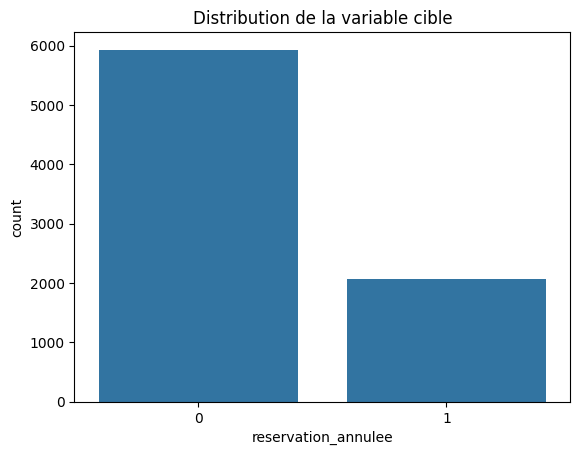

In [261]:
print(df_reservations["reservation_annulee"].value_counts())
sns.countplot(data=df_reservations, x="reservation_annulee")
plt.title("Distribution de la variable cible")
plt.show()

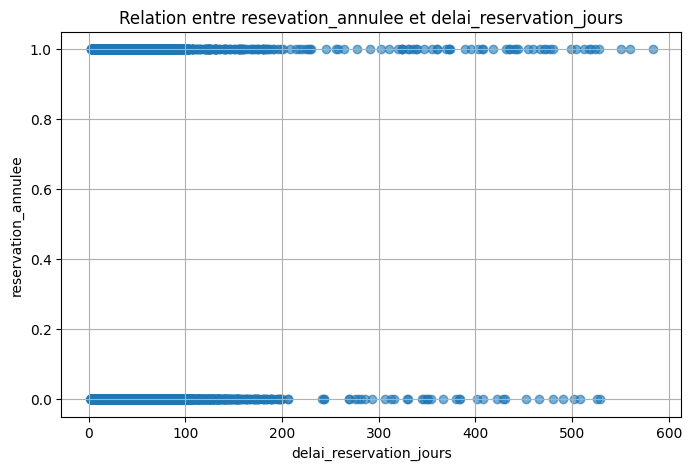

In [262]:
plt.figure(figsize=(8, 5))

plt.scatter(df_reservations["delai_reservation_jours"], df_reservations["reservation_annulee"], alpha=0.6)

plt.xlabel("delai_reservation_jours")
plt.ylabel("reservation_annulee")
plt.title("Relation entre resevation_annulee et delai_reservation_jours")
plt.grid(True)

plt.show()

In [263]:
valeur_max = df_reservations["delai_reservation_jours"].max()
print(valeur_max)

584


## ÉTAPE 2 - BASELINE: Régression Logistique

Nous allons construire un modèle de régression logistique en veillant à ce que tout le prétraitement soit appris uniquement sur l'ensemble d'entraînement pour éviter le data leakage.

In [264]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Définir les caractéristiques (X_train) et la variable cible (y_train) avec toutes les données
X_train = df_reservations.drop('reservation_annulee', axis=1)
y_train = df_reservations['reservation_annulee']

# Nous n'allons pas créer un ensemble de test séparé pour ce modèle baseline,
# le modèle sera entraîné sur l'ensemble complet des données disponibles.

print(f"Taille de l'ensemble d'entraînement (données complètes) : {X_train.shape[0]} échantillons")

Taille de l'ensemble d'entraînement (données complètes) : 8000 échantillons


### Définition des Prétraitements

Nous allons identifier les colonnes numériques et catégorielles. Pour chaque type, nous définirons un pipeline de prétraitement:

*   **Numériques** : Imputation des valeurs manquantes par la médiane, suivie d'une mise à l'échelle standard.
*   **Catégorielles** : Imputation des valeurs manquantes par le mode (valeur la plus fréquente), suivie d'un encodage One-Hot. Nous allons exclure les colonnes identifiantes comme `reservation_id`, `date_reservation`, `date_arrivee`, `hotel_id`, `ville` et `agent_id` car elles ne sont pas pertinentes en tant que caractéristiques directes pour le modèle, ou ont été traitées séparément (dates) ou sont trop granulaires/avec trop de valeurs manquantes (agent_id).

In [265]:
# Définir les colonnes à inclure pour le modèle, basées sur les top corrélations
# Les colonnes one-hot encodées (comme 'tarif_remboursable_oui') sont dérivées de leurs colonnes catégorielles originales (comme 'tarif_remboursable').
# Nous incluons donc les colonnes originales qui, une fois prétraitées, donneront les caractéristiques fortement corrélées.

# Colonnes numériques directement dans le top 10
selected_numerical_cols = ['delai_reservation_jours', 'modifications_reservation', 'remise_pct', 'demandes_speciales', 'chambres']

# Colonnes catégorielles dont les versions encodées sont dans le top 10
selected_categorical_cols = ['tarif_remboursable', 'type_acompte', 'canal_reservation']

print("Colonnes numériques sélectionnées :", selected_numerical_cols)
print("Colonnes catégorielles sélectionnées :", selected_categorical_cols)

# Créer le pipeline de prétraitement pour les caractéristiques numériques
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputer les NaN avec la médiane
    ('scaler', StandardScaler()) # Mettre à l'échelle les caractéristiques numériques
])

# Créer le pipeline de prétraitement pour les caractéristiques catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputer les NaN avec le mode
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Encoder One-Hot les caractéristiques catégorielles
])

# Combiner les prétraitements avec ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, selected_numerical_cols),
        ('cat', categorical_transformer, selected_categorical_cols)
    ],
    remainder='drop' # Supprimer toutes les colonnes non spécifiées
)

print("Prétraitement configuré avec les colonnes sélectionnées.")

Colonnes numériques sélectionnées : ['delai_reservation_jours', 'modifications_reservation', 'remise_pct', 'demandes_speciales', 'chambres']
Colonnes catégorielles sélectionnées : ['tarif_remboursable', 'type_acompte', 'canal_reservation']
Prétraitement configuré avec les colonnes sélectionnées.


### Construction et Entraînement du Modèle de Régression Logistique

Maintenant, nous allons intégrer notre préprocesseur à un modèle de régression logistique dans un pipeline final. Cela garantit que toutes les étapes, de la transformation des données à l'entraînement du modèle, sont appliquées de manière cohérente et que le prétraitement est appris uniquement sur les données d'entraînement.

In [266]:
# Créer le pipeline complet du modèle
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # Utiliser liblinear pour les petits jeux de données et le One-vs-Rest par défaut
])

# Entraîner le pipeline sur les données d'entraînement
model_pipeline.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès sur les données d'entraînement.")

Modèle de régression logistique entraîné avec succès sur les données d'entraînement.


### Évaluation du Modèle de Régression Logistique

Nous allons évaluer le modèle entraîné sur l'ensemble d'entraînement. Bien que cela ne donne pas une indication fiable de la performance sur des données **inconnues**, cela nous permet de vérifier que le modèle s'est bien entraîné et de comprendre comment interpréter les métriques d'évaluation.

In [267]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Faire des prédictions sur l'ensemble d'entraînement
y_pred_train = model_pipeline.predict(X_train)

# Calculer les métriques d'évaluation
accuracy = accuracy_score(y_train, y_pred_train)
precision = precision_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)
conf_matrix = confusion_matrix(y_train, y_pred_train)

print(f"--- Métriques d'évaluation sur l'ensemble d'entraînement ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nMatrice de Confusion :")
print(conf_matrix)

print("\nRapport de Classification :")
print(classification_report(y_train, y_pred_train))

--- Métriques d'évaluation sur l'ensemble d'entraînement ---
Accuracy: 0.7479
Precision: 0.6106
Recall: 0.0668
F1-Score: 0.1204

Matrice de Confusion :
[[5845   88]
 [1929  138]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.75      0.99      0.85      5933
           1       0.61      0.07      0.12      2067

    accuracy                           0.75      8000
   macro avg       0.68      0.53      0.49      8000
weighted avg       0.72      0.75      0.66      8000



### Analyse ROC AUC pour la Régression Logistique (initiale)

Score ROC AUC pour la Régression Logistique (initiale): 0.6857


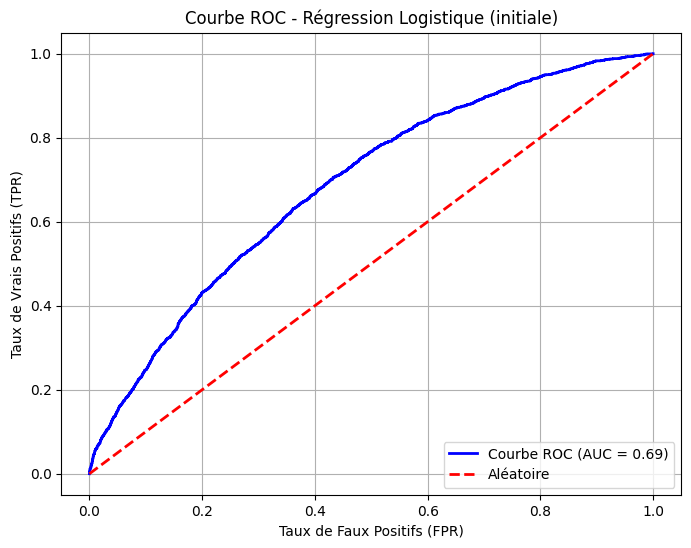

In [268]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba_lr_initial = model_pipeline.predict_proba(X_train)[:, 1]

# Calculer la courbe ROC
fpr_lr_initial, tpr_lr_initial, thresholds_lr_initial = roc_curve(y_train, y_pred_proba_lr_initial)

# Calculer le score ROC AUC
roc_auc_lr_initial = roc_auc_score(y_train, y_pred_proba_lr_initial)

print(f"Score ROC AUC pour la Régression Logistique (initiale): {roc_auc_lr_initial:.4f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_initial, tpr_lr_initial, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc_lr_initial:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Régression Logistique (initiale)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Interprétation des Résultats

*   **Accuracy (Exactitude)** : La proportion de prédictions correctes (aussi bien les annulations que les non-annulations).
*   **Precision (Précision)** : Parmi toutes les réservations prédites comme annulées, quelle proportion a été correctement identifiée ? Une précision élevée signifie peu de faux positifs.
*   **Recall (Rappel)** : Parmi toutes les réservations réellement annulées, quelle proportion a été correctement identifiée par le modèle ? Un rappel élevé signifie peu de faux négatifs.
*   **F1-Score** : La moyenne harmonique de la précision et du rappel. Il est utile lorsque vous voulez équilibrer la précision et le rappel, surtout avec des classes déséquilibrées.
*   **Matrice de Confusion** :
    *   `[0,0]` (True Negative) : Réservations non annulées correctement prédites comme non annulées.
    *   `[0,1]` (False Positive) : Réservations non annulées prédites à tort comme annulées.
    *   `[1,0]` (False Negative) : Réservations annulées prédites à tort comme non annulées.
    *   `[1,1]` (True Positive) : Réservations annulées correctement prédites comme annulées.

In [269]:
print("--- Régression Logistique (initiale) ---")
lr_initial_params = model_pipeline.named_steps['classifier'].get_params()
print(f"  solver: {lr_initial_params.get('solver')}")
print(f"  random_state: {lr_initial_params.get('random_state')}")
print(f"  C: {lr_initial_params.get('C')}")
print(f"  penalty: {lr_initial_params.get('penalty')}")
print("\n")

--- Régression Logistique (initiale) ---
  solver: liblinear
  random_state: 42
  C: 1.0
  penalty: l2




### Ajustement du Seuil de Décision pour Améliorer le Rappel

Étant donné le faible rappel pour la classe '1' (réservations annulées) et le nombre élevé de faux négatifs, nous allons ajuster le seuil de décision du modèle. Le seuil par défaut est généralement de 0.5, mais nous pouvons le réduire pour que le modèle soit plus enclin à prédire une annulation, augmentant ainsi le rappel aux dépens potentiellement de la précision.

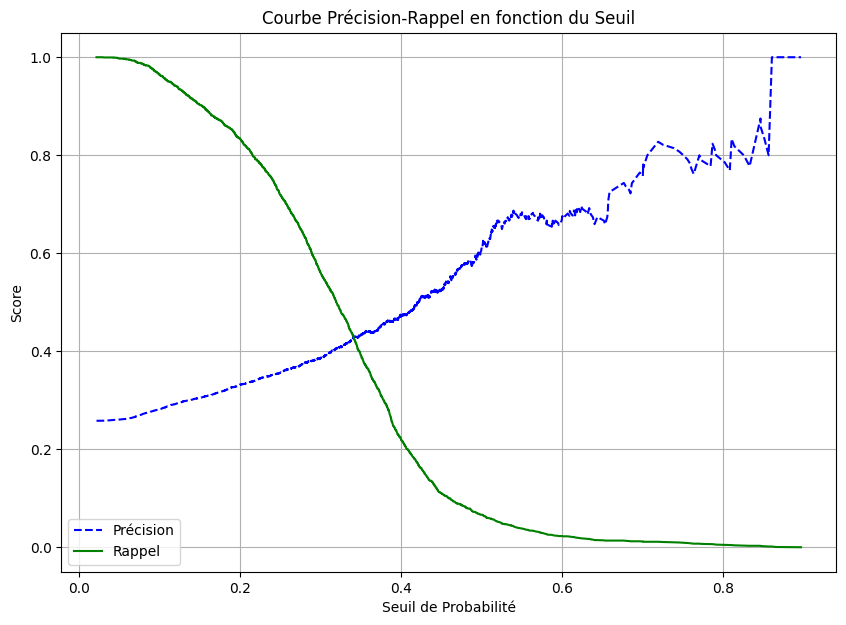

In [270]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba = model_pipeline.predict_proba(X_train)[:, 1]

# Calculer la précision, le rappel et les seuils pour différentes probabilités
precisions, recalls, thresholds = precision_recall_curve(y_train, y_pred_proba)

# Tracer la courbe précision-rappel
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precisions[:-1], 'b--', label='Précision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Rappel')
plt.xlabel('Seuil de Probabilité')
plt.ylabel('Score')
plt.title('Courbe Précision-Rappel en fonction du Seuil')
plt.legend()
plt.grid(True)
plt.show()

### Sélection d'un Nouveau Seuil et Réévaluation

En fonction de la courbe Précision-Rappel, nous pouvons choisir un seuil qui offre un meilleur équilibre entre précision et rappel pour notre objectif (par exemple, privilégier un rappel plus élevé pour mieux détecter les annulations).

Pour l'exemple, nous allons choisir un seuil pour lequel le rappel est significativement amélioré, même si cela peut réduire légèrement la précision. Nous pourrions par exemple viser un rappel de 0.5 (50% des annulations détectées).

In [271]:
# Trouver le seuil qui correspond à un certain niveau de rappel (par exemple, 0.5)
# Ou simplement choisir un seuil visuellement à partir du graphique

# Pour l'exemple, choisissons un seuil de 0.2 (vous pouvez l'ajuster en fonction du graphique ci-dessus)
new_threshold = 0.2 # <--- Ajustez ce seuil en fonction de vos observations

# Appliquer le nouveau seuil pour obtenir les prédictions binaires
y_pred_train_new_threshold = (y_pred_proba >= new_threshold).astype(int)

# Réévaluer le modèle avec le nouveau seuil
accuracy_new = accuracy_score(y_train, y_pred_train_new_threshold)
precision_new = precision_score(y_train, y_pred_train_new_threshold)
recall_new = recall_score(y_train, y_pred_train_new_threshold)
f1_new = f1_score(y_train, y_pred_train_new_threshold)
conf_matrix_new = confusion_matrix(y_train, y_pred_train_new_threshold)

print(f"--- Métriques d'évaluation sur l'ensemble d'entraînement (Seuil = {new_threshold}) ---")
print(f"Accuracy: {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall: {recall_new:.4f}")
print(f"F1-Score: {f1_new:.4f}")
print("\nMatrice de Confusion :")
print(conf_matrix_new)

print("\nRapport de Classification :")
print(classification_report(y_train, y_pred_train_new_threshold))

--- Métriques d'évaluation sur l'ensemble d'entraînement (Seuil = 0.2) ---
Accuracy: 0.5240
Precision: 0.3323
Recall: 0.8345
F1-Score: 0.4753

Matrice de Confusion :
[[2467 3466]
 [ 342 1725]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.88      0.42      0.56      5933
           1       0.33      0.83      0.48      2067

    accuracy                           0.52      8000
   macro avg       0.61      0.63      0.52      8000
weighted avg       0.74      0.52      0.54      8000



### Optimisation des Hyperparamètres de la Régression Logistique avec GridSearchCV

Pour tenter d'améliorer les performances de notre modèle de régression logistique, nous allons optimiser ses hyperparamètres en utilisant `GridSearchCV`. Cette technique explore différentes combinaisons de paramètres pour trouver celle qui donne la meilleure performance selon une métrique spécifiée (par exemple, le F1-score, le rappel ou la précision).

In [272]:
from sklearn.model_selection import GridSearchCV

# Définir la grille de paramètres à tester pour le classifieur LogisticRegression
# Le préfixe 'classifier__' fait référence au nom de l'étape du classifieur dans le pipeline.
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse de la force de régularisation; plus petit C signifie une régularisation plus forte
    'classifier__penalty': ['l1', 'l2'], # Type de régularisation
    'classifier__solver': ['liblinear'] # 'liblinear' supporte à la fois 'l1' et 'l2'
}

# Initialiser GridSearchCV
# Nous utiliserons le F1-score comme métrique d'évaluation car il est adapté aux classes déséquilibrées.
# 'recall' ou 'precision' pourraient aussi être des choix pertinents en fonction de l'objectif métier.
grid_search = GridSearchCV(
    model_pipeline, # Notre pipeline existant
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1', # Utiliser le F1-score pour évaluer les modèles
    n_jobs=-1, # Utiliser tous les cœurs de processeur disponibles
    verbose=1
)

# Exécuter la recherche par grille sur les données d'entraînement
print("Début de la recherche par grille pour l'optimisation des hyperparamètres...")
grid_search.fit(X_train, y_train)

print("Recherche par grille terminée.")

Début de la recherche par grille pour l'optimisation des hyperparamètres...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Recherche par grille terminée.


### Résultats de l'Optimisation des Hyperparamètres

Après la recherche par grille, nous pouvons examiner les meilleurs paramètres trouvés et évaluer les performances du modèle de régression logistique avec ces paramètres optimisés.

In [273]:
from sklearn.metrics import classification_report, confusion_matrix

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres trouvés :", grid_search.best_params_)
print("Meilleur F1-score de validation croisée :", grid_search.best_score_)

# Obtenir le meilleur modèle (le pipeline avec les hyperparamètres optimisés)
best_logistic_model = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble d'entraînement avec le meilleur modèle
y_pred_train_optimized = best_logistic_model.predict(X_train)

# Afficher la matrice de confusion et le rapport de classification pour le modèle optimisé
print("\nMatrice de Confusion (Régression Logistique Optimisée) :")
print(confusion_matrix(y_train, y_pred_train_optimized))

print("\nRapport de Classification (Régression Logistique Optimisée) :")
print(classification_report(y_train, y_pred_train_optimized))

# Obtenir les probabilités pour ajuster éventuellement le seuil si nécessaire
y_pred_proba_optimized = best_logistic_model.predict_proba(X_train)[:, 1]

# Nous pourrions de nouveau tracer la courbe Précision-Rappel pour le modèle optimisé
# et ajuster le seuil si les performances par défaut ne sont pas encore optimales pour nos besoins.

Meilleurs paramètres trouvés : {'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Meilleur F1-score de validation croisée : 0.12518780631178533

Matrice de Confusion (Régression Logistique Optimisée) :
[[5844   89]
 [1930  137]]

Rapport de Classification (Régression Logistique Optimisée) :
              precision    recall  f1-score   support

           0       0.75      0.98      0.85      5933
           1       0.61      0.07      0.12      2067

    accuracy                           0.75      8000
   macro avg       0.68      0.53      0.49      8000
weighted avg       0.71      0.75      0.66      8000



### Analyse ROC AUC pour la Régression Logistique (optimisée)

Score ROC AUC pour la Régression Logistique (optimisée): 0.6857


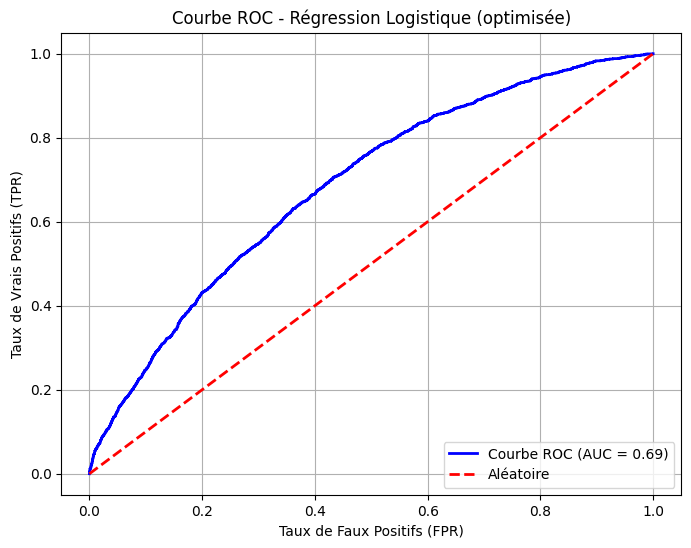

In [274]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba_lr_optimized = best_logistic_model.predict_proba(X_train)[:, 1]

# Calculer la courbe ROC
fpr_lr_optimized, tpr_lr_optimized, thresholds_lr_optimized = roc_curve(y_train, y_pred_proba_lr_optimized)

# Calculer le score ROC AUC
roc_auc_lr_optimized = roc_auc_score(y_train, y_pred_proba_lr_optimized)

print(f"Score ROC AUC pour la Régression Logistique (optimisée): {roc_auc_lr_optimized:.4f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_optimized, tpr_lr_optimized, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc_lr_optimized:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Régression Logistique (optimisée)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [275]:
print("--- Régression Logistique (optimisée) ---")
# Les meilleurs paramètres sont stockés dans grid_search.best_params_
print(grid_search.best_params_)
print("\n")

--- Régression Logistique (optimisée) ---
{'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}




### Construction et Entraînement d'un Modèle K-Nearest Neighbors (KNN)

Nous allons maintenant ajouter un modèle K-Nearest Neighbors (KNN) à notre pipeline. Le prétraitement des données restera le même.

In [276]:
from sklearn.neighbors import KNeighborsClassifier

# Créer le pipeline complet du modèle avec KNN
# Nous allons commencer avec des paramètres par défaut pour le baseline du KNN
model_pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Entraîner le pipeline sur les données d'entraînement
model_pipeline_knn.fit(X_train, y_train)

print("Modèle K-Nearest Neighbors entraîné avec succès sur les données d'entraînement.")

Modèle K-Nearest Neighbors entraîné avec succès sur les données d'entraînement.


### Évaluation du Modèle K-Nearest Neighbors (KNN)

Nous allons évaluer le modèle KNN entraîné sur l'ensemble d'entraînement et comparer ses performances avec celles des modèles précédents.

In [277]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Faire des prédictions sur l'ensemble d'entraînement avec le modèle KNN
y_pred_train_knn = model_pipeline_knn.predict(X_train)

# Calculer les métriques d'évaluation
accuracy_knn = accuracy_score(y_train, y_pred_train_knn)
precision_knn = precision_score(y_train, y_pred_train_knn)
recall_knn = recall_score(y_train, y_pred_train_knn)
f1_knn = f1_score(y_train, y_pred_train_knn)
conf_matrix_knn = confusion_matrix(y_train, y_pred_train_knn)

print(f"--- Métriques d'évaluation sur l'ensemble d'entraînement (KNN) ---")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print("\nMatrice de Confusion (KNN) :")
print(conf_matrix_knn)

print("\nRapport de Classification (KNN) :")
print(classification_report(y_train, y_pred_train_knn))

--- Métriques d'évaluation sur l'ensemble d'entraînement (KNN) ---
Accuracy: 0.7871
Precision: 0.6540
Recall: 0.3740
F1-Score: 0.4758

Matrice de Confusion (KNN) :
[[5524  409]
 [1294  773]]

Rapport de Classification (KNN) :
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      5933
           1       0.65      0.37      0.48      2067

    accuracy                           0.79      8000
   macro avg       0.73      0.65      0.67      8000
weighted avg       0.77      0.79      0.77      8000



### Analyse ROC AUC pour le Modèle K-Nearest Neighbors (KNN)

Score ROC AUC pour le KNN: 0.8166


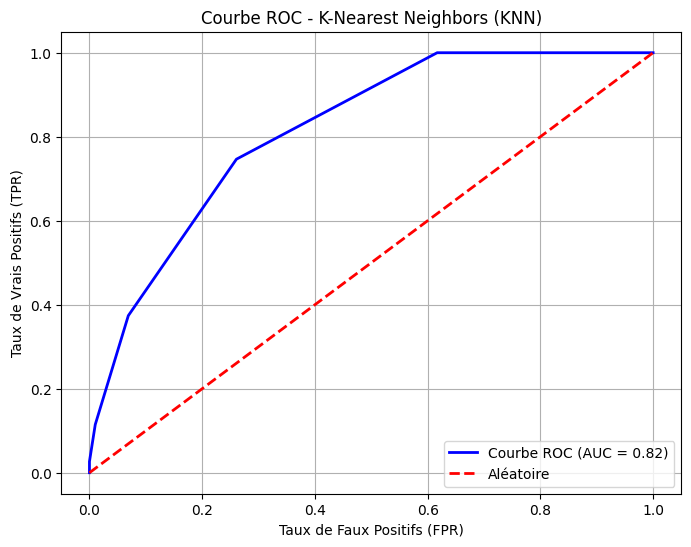

In [278]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba_knn = model_pipeline_knn.predict_proba(X_train)[:, 1]

# Calculer la courbe ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_train, y_pred_proba_knn)

# Calculer le score ROC AUC
roc_auc_knn = roc_auc_score(y_train, y_pred_proba_knn)

print(f"Score ROC AUC pour le KNN: {roc_auc_knn:.4f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - K-Nearest Neighbors (KNN)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [279]:
print("--- K-Nearest Neighbors (KNN) ---")
knn_params = model_pipeline_knn.named_steps['classifier'].get_params()
print(f"  n_neighbors: {knn_params.get('n_neighbors')}")
print(f"  weights: {knn_params.get('weights')}")
print(f"  metric: {knn_params.get('metric')}")
print("\n")

--- K-Nearest Neighbors (KNN) ---
  n_neighbors: 5
  weights: uniform
  metric: minkowski




### Construction et Entraînement d'un Modèle Naive Bayes

Nous allons maintenant ajouter un modèle Naive Bayes (GaussianNB) à notre pipeline. Le prétraitement des données restera le même.

In [280]:
from sklearn.naive_bayes import GaussianNB

# Créer le pipeline complet du modèle avec Gaussian Naive Bayes
model_pipeline_gnb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Entraîner le pipeline sur les données d'entraînement
model_pipeline_gnb.fit(X_train, y_train)

print("Modèle Gaussian Naive Bayes entraîné avec succès sur les données d'entraînement.")

Modèle Gaussian Naive Bayes entraîné avec succès sur les données d'entraînement.


### Évaluation du Modèle Naive Bayes

Nous allons évaluer le modèle Naive Bayes entraîné sur l'ensemble d'entraînement et comparer ses performances avec celles des modèles précédents.

In [281]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Faire des prédictions sur l'ensemble d'entraînement avec le modèle Naive Bayes
y_pred_train_gnb = model_pipeline_gnb.predict(X_train)

# Calculer les métriques d'évaluation
accuracy_gnb = accuracy_score(y_train, y_pred_train_gnb)
precision_gnb = precision_score(y_train, y_pred_train_gnb)
recall_gnb = recall_score(y_train, y_pred_train_gnb)
f1_gnb = f1_score(y_train, y_pred_train_gnb)
conf_matrix_gnb = confusion_matrix(y_train, y_pred_train_gnb)

print(f"--- Métriques d'évaluation sur l'ensemble d'entraînement (Naive Bayes) ---")
print(f"Accuracy: {accuracy_gnb:.4f}")
print(f"Precision: {precision_gnb:.4f}")
print(f"Recall: {recall_gnb:.4f}")
print(f"F1-Score: {f1_gnb:.4f}")
print("\nMatrice de Confusion (Naive Bayes) :")
print(conf_matrix_gnb)

print("\nRapport de Classification (Naive Bayes) :")
print(classification_report(y_train, y_pred_train_gnb))

--- Métriques d'évaluation sur l'ensemble d'entraînement (Naive Bayes) ---
Accuracy: 0.6482
Precision: 0.3785
Recall: 0.5631
F1-Score: 0.4527

Matrice de Confusion (Naive Bayes) :
[[4022 1911]
 [ 903 1164]]

Rapport de Classification (Naive Bayes) :
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      5933
           1       0.38      0.56      0.45      2067

    accuracy                           0.65      8000
   macro avg       0.60      0.62      0.60      8000
weighted avg       0.70      0.65      0.67      8000



### Analyse ROC AUC pour le Modèle Naive Bayes

Score ROC AUC pour le Naive Bayes: 0.6787


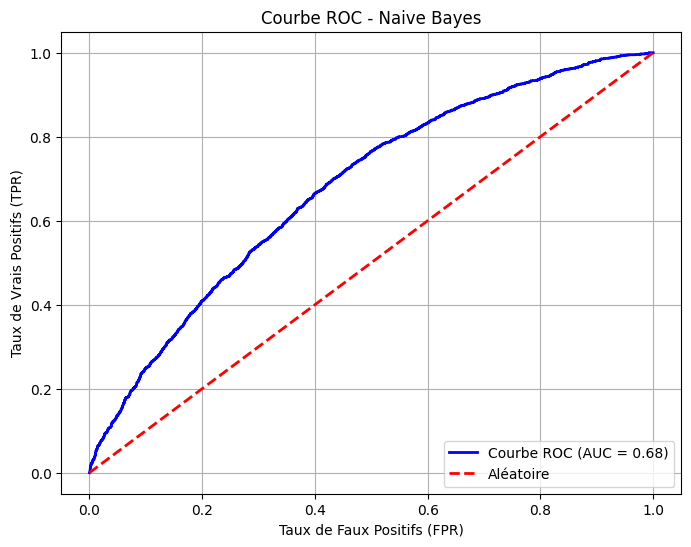

In [282]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba_gnb = model_pipeline_gnb.predict_proba(X_train)[:, 1]

# Calculer la courbe ROC
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_train, y_pred_proba_gnb)

# Calculer le score ROC AUC
roc_auc_gnb = roc_auc_score(y_train, y_pred_proba_gnb)

print(f"Score ROC AUC pour le Naive Bayes: {roc_auc_gnb:.4f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc_gnb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [283]:
print("--- Naive Bayes (GaussianNB) ---")
gnb_params = model_pipeline_gnb.named_steps['classifier'].get_params()
# GaussianNB a peu de paramètres à afficher explicitement, il utilise principalement les statistiques des données.
print(gnb_params)
print("\n")

--- Naive Bayes (GaussianNB) ---
{'priors': None, 'var_smoothing': 1e-09}




### Construction et Entraînement d'un Modèle Random Forest

Nous allons maintenant remplacer la régression logistique par un `RandomForestClassifier` dans notre pipeline. Le prétraitement des données restera le même.

In [284]:
from sklearn.ensemble import RandomForestClassifier

# Créer le pipeline complet du modèle avec Random Forest
# Nous allons commencer avec des paramètres par défaut pour le baseline du Random Forest
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entraîner le pipeline sur les données d'entraînement
model_pipeline_rf.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès sur les données d'entraînement.")

Modèle Random Forest entraîné avec succès sur les données d'entraînement.


### Évaluation du Modèle Random Forest

Nous allons évaluer le modèle Random Forest entraîné sur l'ensemble d'entraînement et comparer ses performances (notamment la précision et le rappel) avec celles de la régression logistique.

In [285]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Faire des prédictions sur l'ensemble d'entraînement avec le modèle Random Forest
y_pred_train_rf = model_pipeline_rf.predict(X_train)

# Calculer les métriques d'évaluation
accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
precision_rf = precision_score(y_train, y_pred_train_rf)
recall_rf = recall_score(y_train, y_pred_train_rf)
f1_rf = f1_score(y_train, y_pred_train_rf)
conf_matrix_rf = confusion_matrix(y_train, y_pred_train_rf)

print(f"--- Métriques d'évaluation sur l'ensemble d'entraînement (Random Forest) ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print("\nMatrice de Confusion (Random Forest) :")
print(conf_matrix_rf)

print("\nRapport de Classification (Random Forest) :")
print(classification_report(y_train, y_pred_train_rf))

--- Métriques d'évaluation sur l'ensemble d'entraînement (Random Forest) ---
Accuracy: 0.9809
Precision: 0.9696
Recall: 0.9560
F1-Score: 0.9627

Matrice de Confusion (Random Forest) :
[[5871   62]
 [  91 1976]]

Rapport de Classification (Random Forest) :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5933
           1       0.97      0.96      0.96      2067

    accuracy                           0.98      8000
   macro avg       0.98      0.97      0.97      8000
weighted avg       0.98      0.98      0.98      8000



### Analyse ROC AUC pour le Modèle Random Forest (initial)

Score ROC AUC pour le Random Forest (initial): 0.9985


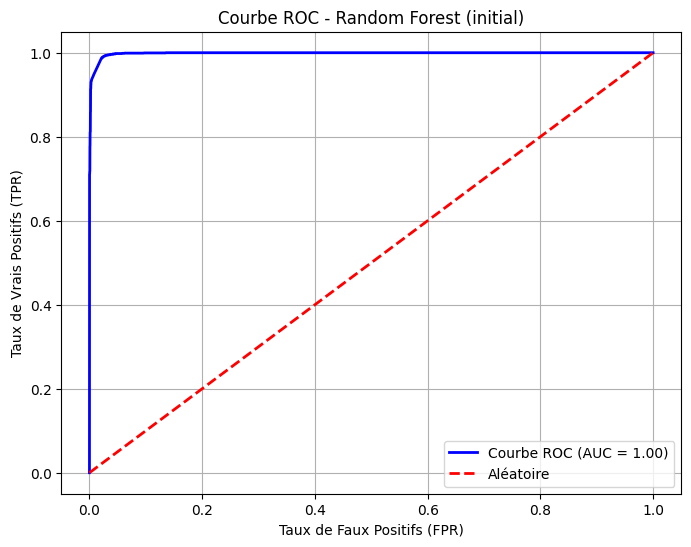

In [286]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtenir les probabilités de la classe positive (classe 1 - annulée)
y_pred_proba_rf_initial = model_pipeline_rf.predict_proba(X_train)[:, 1]

# Calculer la courbe ROC
fpr_rf_initial, tpr_rf_initial, thresholds_rf_initial = roc_curve(y_train, y_pred_proba_rf_initial)

# Calculer le score ROC AUC
roc_auc_rf_initial = roc_auc_score(y_train, y_pred_proba_rf_initial)

print(f"Score ROC AUC pour le Random Forest (initial): {roc_auc_rf_initial:.4f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_initial, tpr_rf_initial, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc_rf_initial:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Random Forest (initial)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Application du Modèle Random Forest sur l'Ensemble de Test

Pour évaluer la capacité de généralisation de notre modele, nous allons l'appliquer sur le jeu de données de test, `reservations_test.csv`. Il est crucial d'appliquer les mêmes étapes de prétraitement.

In [287]:
print("--- Random Forest (initial) ---")
rf_initial_params = model_pipeline_rf.named_steps['classifier'].get_params()
print(f"  random_state: {rf_initial_params.get('random_state')}")
print(f"  n_estimators: {rf_initial_params.get('n_estimators')}")
print(f"  max_depth: {rf_initial_params.get('max_depth')}")
print(f"  min_samples_leaf: {rf_initial_params.get('min_samples_leaf')}")
print(f"  min_samples_split: {rf_initial_params.get('min_samples_split')}")
print("\n")

--- Random Forest (initial) ---
  random_state: 42
  n_estimators: 100
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2




In [288]:
# Charger le fichier CSV du testset
df_test = pd.read_csv('ressources/reservations_test.csv')

print("Aperçu du jeu de données de test :")
display(df_test.head())

print(f"Taille de l'ensemble de test : {df_test.shape[0]} échantillons")

Aperçu du jeu de données de test :


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id
0,R002267,2025-05-24,2025-07-09,Lazio,Roma,urbaine_culturelle,LAZ-4-2,4,famille,Italie,...,nouveau,0,0,0.0,0,0,0,0,0,AG033
1,R002852,2025-05-24,2025-05-29,Lombardia,Milano,affaires_lacs,LOM-4-2,4,affaires,Italie,...,nouveau,0,0,1.0,1,0,0,1,0,NaN
2,R003752,2025-05-24,2025-06-25,Lombardia,Milano,affaires_lacs,LOM-3-1,3,famille,Europe_Ouest,...,nouveau,0,0,1.0,0,0,0,0,0,AG027
3,R009926,2025-05-24,2025-07-21,Sicilia,Palermo,insulaire_mixte,SIC-4-1,4,solo,Italie,...,nouveau,0,0,1.0,0,0,0,1,0,AG003
4,R000141,2025-05-25,2025-06-12,Sicilia,Palermo,insulaire_mixte,SIC-4-2,4,affaires,Europe_Ouest,...,nouveau,0,0,0.0,0,0,0,1,0,AG006


Taille de l'ensemble de test : 2000 échantillons


In [289]:
# Séparer les caractéristiques (X_test) et la variable cible (y_test) si elle est présente
# Dans un cas réel de prédiction, le testset n'aurait pas 'reservation_annulee'.
# Pour l'évaluation ici, nous supposons qu'elle est présente.

if 'reservation_annulee' in df_test.columns:
    X_test = df_test.drop('reservation_annulee', axis=1)
    y_test = df_test['reservation_annulee']
    print("La variable cible 'reservation_annulee' est présente dans le testset.")
else:
    X_test = df_test
    y_test = None # Pas de variable cible pour l'évaluation si elle est absente
    print("La variable cible 'reservation_annulee' est absente du testset. Seules les prédictions seront effectuées.")

# Faire des prédictions sur l'ensemble de test avec le modèle Random Forest initial
y_pred_test_rf_initial = model_pipeline_rf.predict(X_test)

print("Prédictions générées avec succès sur le jeu de données de test avec le modèle Random Forest initial.")

# Si y_test est disponible, nous pouvons évaluer les performances
if y_test is not None:
    print("\n--- Évaluation des performances sur l'ensemble de test (Random Forest Initial) ---")
    accuracy_test_rf_initial = accuracy_score(y_test, y_pred_test_rf_initial)
    precision_test_rf_initial = precision_score(y_test, y_pred_test_rf_initial)
    recall_test_rf_initial = recall_score(y_test, y_pred_test_rf_initial)
    f1_test_rf_initial = f1_score(y_test, y_pred_test_rf_initial)
    conf_matrix_test_rf_initial = confusion_matrix(y_test, y_pred_test_rf_initial)

    print(f"Accuracy: {accuracy_test_rf_initial:.4f}")
    print(f"Precision: {precision_test_rf_initial:.4f}")
    print(f"Recall: {recall_test_rf_initial:.4f}")
    print(f"F1-Score: {f1_test_rf_initial:.4f}")
    print("\nMatrice de Confusion :")
    print(conf_matrix_test_rf_initial)
    print("\nRapport de Classification :")
    print(classification_report(y_test, y_pred_test_rf_initial))
else:
    print("Les prédictions du modèle sur le testset (y_pred_test_rf_initial) sont disponibles.")
    print("Voici les 5 premières prédictions :", y_pred_test_rf_initial[:5])

La variable cible 'reservation_annulee' est absente du testset. Seules les prédictions seront effectuées.
Prédictions générées avec succès sur le jeu de données de test avec le modèle Random Forest initial.
Les prédictions du modèle sur le testset (y_pred_test_rf_initial) sont disponibles.
Voici les 5 premières prédictions : [0 0 0 1 0]


In [290]:
y_pred_proba_test_rf_initial = model_pipeline_rf.predict_proba(X_test)[:, 1]

print("Probabilités d'annulation (classe 1) pour le testset (5 premières prédictions) :")
display(y_pred_proba_test_rf_initial[:5])

Probabilités d'annulation (classe 1) pour le testset (5 premières prédictions) :


array([0.16      , 0.07      , 0.32166667, 0.57342857, 0.19916667])

In [291]:
# Créer un DataFrame avec les identifiants de réservation du testset
df_submission = pd.DataFrame({'reservation_id': X_test['reservation_id']})

# Ajouter la colonne des probabilités d'annulation
df_submission['probabilite_annulation'] = y_pred_proba_test_rf_initial

# Ajouter la colonne des prédictions binaires d'annulation
df_submission['reservation_annulee'] = y_pred_test_rf_initial

# Afficher le DataFrame de soumission entier
print("Aperçu du DataFrame de soumission :")
display(df_submission)

Aperçu du DataFrame de soumission :


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.160000,0
1,R002852,0.070000,0
2,R003752,0.321667,0
3,R009926,0.573429,1
4,R000141,0.199167,0
...,...,...,...
1995,R007898,0.230000,0
1996,R008160,0.210000,0
1997,R008422,0.276000,0
1998,R008848,0.300000,0


Ces valeurs représentent la probabilité que le modèle Random Forest prédise une annulation (classe 1) pour chaque réservation du jeu de données de test. Plus la valeur est proche de 1, plus la probabilité d'annulation est élevée, et plus elle est proche de 0, plus la probabilité de non-annulation est élevée.

In [292]:
total_annulees_predites = df_submission['reservation_annulee'].value_counts().get(1, 0)
print(f"Nombre total de réservations prédites comme annulées : {total_annulees_predites}")

Nombre total de réservations prédites comme annulées : 340


In [293]:
# Enregistrer le DataFrame au format CSV
df_submission.to_csv('submission.csv', index=False)

print("Le fichier 'submission.csv' a été créé avec succès.")

Le fichier 'submission.csv' a été créé avec succès.
